In [9]:
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict

In [10]:
load_dotenv()

True

In [11]:
class QAState(TypedDict):
    question: str
    answer: str

In [12]:
def generateAnswer(state: QAState) -> QAState:
    question = state.get("question","")
    llm = ChatOpenAI()
    result = llm.invoke(question).content
    state["answer"] = result
    return state
    


In [13]:
graph = StateGraph(QAState)
graph.add_node('generateAnswer',generateAnswer)

graph.add_edge(START,"generateAnswer")
graph.add_edge("generateAnswer",END)

workflow = graph.compile()

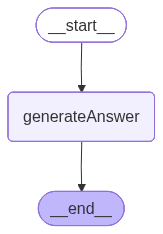

In [14]:
workflow

In [15]:
intial_state = {"question": "What it the capital of India?"}
final_state= workflow.invoke(intial_state)
print(f"final_state: {final_state}")

final_state: {'question': 'What it the capital of India?', 'answer': 'The capital of India is New Delhi.'}


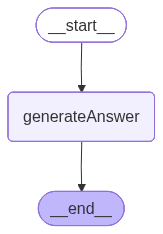

In [17]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())